In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os


# feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from PROPS_EV.calculateEVS import *
from BACKTEST.backtest import *

In [3]:
model = joblib.load('Models/xgbModel.pkl')
features = joblib.load('Models/top_features.pkl')

In [4]:
pd.set_option('display.max_columns', None)
eplison = 0.000001

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')

In [5]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['CATEGORY'] == 'player_points') & (backtestData['BOOKMAKER'] == 'fanduel')]
backtestData

C:\Users\alexg\AppData\Local\Temp\ipykernel_19108\4219844122.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
42934,42934,42934,42934,Cameron Johnson,player_points,fanduel,over,24.5,-137,Toronto Raptors,Brooklyn Nets,NaN,NaN,2025-01-02,game,23.5,-108.0,over
42947,42947,42947,42947,Immanuel Quickley,player_points,fanduel,over,14.5,-137,Toronto Raptors,Brooklyn Nets,NaN,NaN,2025-01-02,game,15.5,100.0,over
42965,42965,42965,42965,Immanuel Quickley,player_points,fanduel,under,14.5,-137,Toronto Raptors,Brooklyn Nets,NaN,NaN,2025-01-02,game,15.5,100.0,under
43030,43030,43030,43030,Josh Hart,player_points,fanduel,under,15.5,-137,New York Knicks,Utah Jazz,NaN,NaN,2025-01-02,game,14.5,109.0,under
43031,43031,43031,43031,Jordan Clarkson,player_points,fanduel,under,27.5,-137,New York Knicks,Utah Jazz,NaN,NaN,2025-01-02,game,19.5,-109.0,under
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197996,197996,197996,119035,Jonathan Mogbo,player_points,fanduel,under,14.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,15.0,100.0,under
198003,198003,198003,119042,Jamal Shead,player_points,fanduel,over,15.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,16.5,124.0,over
198010,198010,198010,119049,Jamal Shead,player_points,fanduel,under,15.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,16.5,-124.0,under
198013,198013,198013,119052,Jamison Battle,player_points,fanduel,under,13.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,18.5,156.0,under


In [31]:
results = backtestPrizePicksPairs(df, backtestData, '2025-01-02')
results

Processing PrizePicks pairs...


,player1,player2,side1,side2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,kelly_full,date
0,Cameron Johnson,Lauri Markkanen,over,over,UNDER,OVER,24.5,10.5,17.42,17.64,26,16,-7.08,7.14,0,1,1,0,1.559,0.8531,0.780,2025-01-02
1,Cameron Johnson,Jordan Clarkson,over,under,UNDER,UNDER,24.5,27.5,17.42,19.57,26,25,-7.08,-7.93,0,1,1,0,1.311,0.7703,0.656,2025-01-02
2,Cameron Johnson,Walker Kessler,over,under,UNDER,OVER,24.5,6.5,17.42,9.82,26,6,-7.08,3.32,0,0,0,0,1.101,0.7003,0.550,2025-01-02
3,Cameron Johnson,Immanuel Quickley,over,over,UNDER,OVER,24.5,14.5,17.42,18.01,26,21,-7.08,3.51,0,1,0,0,1.058,0.6861,0.529,2025-01-02
4,Immanuel Quickley,Lauri Markkanen,over,over,OVER,OVER,14.5,10.5,18.01,17.64,21,16,3.51,7.14,1,1,0,1,1.020,0.6732,0.510,2025-01-02
5,Immanuel Quickley,Jordan Clarkson,over,under,OVER,UNDER,14.5,27.5,18.01,19.57,21,25,3.51,-7.93,1,1,0,1,0.824,0.6079,0.412,2025-01-02
6,Cameron Johnson,Josh Hart,over,under,UNDER,UNDER,24.5,15.5,17.42,14.37,26,15,-7.08,-1.13,0,1,0,0,0.693,0.5644,0.347,2025-01-02
7,Josh Hart,Lauri Markkanen,under,over,UNDER,OVER,15.5,10.5,14.37,17.64,15,16,-1.13,7.14,1,1,0,1,0.661,0.5538,0.331,2025-01-02
8,Cameron Johnson,Mikal Bridges,over,under,UNDER,UNDER,24.5,22.5,17.42,21.02,26,27,-7.08,-1.48,0,0,0,0,0.659,0.5529,0.329,2025-01-02
9,Immanuel Quickley,Walker Kessler,over,under,OVER,OVER,14.5,6.5,18.01,9.82,21,6,3.51,3.32,1,0,0,0,0.658,0.5527,0.329,2025-01-02


In [19]:
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")


--- All Bets ---
Total: 10, Wins: 5, Win Rate: 50.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 4, Wins: 3, Win Rate: 75.00%


In [32]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPrizePicksPairs(df, backtestData, date, edge_threshold=5.5, top_n=3)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
No bets found for 2024-10-22
  No results for 2024-10-22
Processing 2024-10-23... 2/163
No bets found for 2024-10-23
  No results for 2024-10-23
Processing 2024-10-24... 3/163
No bets found for 2024-10-24
  No results for 2024-10-24
Processing 2024-10-25... 4/163
No bets found for 2024-10-25
  No results for 2024-10-25
Processing 2024-10-26... 5/163
No bets found for 2024-10-26
  No results for 2024-10-26
Processing 2024-10-27... 6/163
No bets found for 2024-10-27
  No results for 2024-10-27
Processing 2024-10-28... 7/163
No bets found for 2024-10-28
  No results for 2024-10-28
Processing 2024-10-29... 8/163
No bets found for 2024-10-29
  No results for 2024-10-29
Processing 2024-10-30... 9/163
No bets found for 2024-10-30
  No results for 2024-10-30
Processing 2024-10-31... 10/163
No bets found for 2024-10-31
  No results for 2024-10-31
Processing 2024-11-01... 11/163
No bets found for 2024-11-01
  No results for 2024-11-01
Processing 2024-11-02... 12/16

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 426
   Wins: 236
   Hit Rate: 55.40%
   Total Profit: $-177.37
   Total Staked: $4,260.00
   ROI: -4.16%
   Volatility: $19.53
   Max Drawdown: $-427.66
   Sharpe Ratio: -0.762

 RECOMMENDED BETS ANALYSIS (Edge > 5):
   Total Bets: 149
   Wins: 89
   Hit Rate: 59.73%
   Total Profit: $49.64
   Total Staked: $1,490.00
   ROI: 3.33%
   Volatility: $13.19
   Max Drawdown: $-78.10
   Sharpe Ratio: 0.413


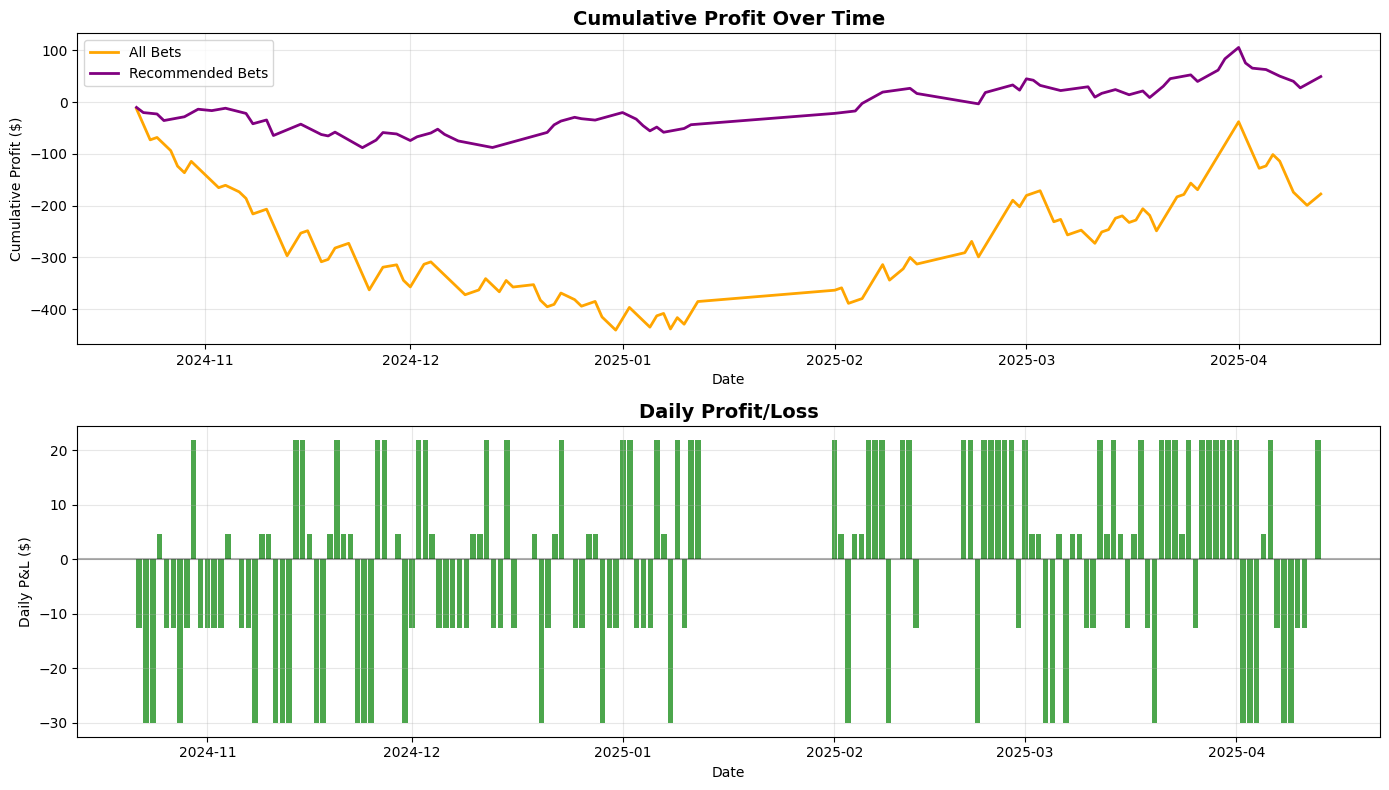

In [9]:
final_results = pd.read_csv('pairs_underdog_5.csv')
edge = 5
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results, stake=10)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=10)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()